In [1]:
print("gello")

gello


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.stats_dataset import analyser_variables_binaires
from utils.feature_transformer import transform_features, _convert_all_columns_to_numeric
from utils.data_quality import nettoyer_nan_par_colonne
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
from utils.feature_loader import load_feature_lists, load_diagnostic_feature_map
import sys
# loads the col
FEATURE_CONFIG_PATH = "utils/feature_columns.json"
feature_lists = load_feature_lists(FEATURE_CONFIG_PATH)
Liste_features_simple = feature_lists["Liste_features_simple"]
features_radiology_dysfunction = feature_lists["features_radiology_dysfunction"]
features_etiology = feature_lists["features_etiology"]
features_death = feature_lists["death"]
# Charger le fichier Excel
df = pd.read_excel(r"C:\Users\romai\Desktop\travail\EFRAIM3 JD VANCE.xlsx")

# separer colonnes explicatives et etiology
df = df[df['Etiology_Undetermined cause_Definitive diagnosis'] != 1]
features_etiology.remove('Etiology_Undetermined cause_Definitive diagnosis')

diagnostic_feature_map = load_diagnostic_feature_map(
    FEATURE_CONFIG_PATH,
    available_columns=df.columns,
    diagnoses = ["Bacterial infection","default"]
)
all_feature_columns = []
for columns_list in diagnostic_feature_map.values():
    for feature_name in columns_list:
        if feature_name not in all_feature_columns:
            all_feature_columns.append(feature_name)
Liste_features = all_feature_columns
df_col_utils = df[Liste_features]
df_category = df[features_etiology]
df_death = df[features_death]
DIAGNOSTIC_FEATURES = diagnostic_feature_map
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","Neutrophils","Temp","Sp02","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}
strategie_fill_nan["DG1"] = "str"
strategie_fill_nan["DG2"] = "str"
strategie_fill_nan["Sys_dis_spec"] = "str"
df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
# resultats = analyser_nan(df_col_utils, top_n=3)
# resultats_y = analyser_nan(df_category, top_n=8)
df_category = nettoyer_colonnes(df_category)
df_cat_clean,index_a_drop = nettoyer_lignes_vides(df_category)
df_features_clean = df_features_clean.drop(index=index_a_drop)
df_features_clean = _convert_all_columns_to_numeric(df_features_clean)

🔹 Age → NaN remplacés par la médiane (64.0)
🔹 Time H-ICU → NaN remplacés par la médiane (2.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (2.0)
🔹 SOFA_score → NaN remplacés par la médiane (7.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 Temp → NaN remplacés par la médiane (37.3)
🔹 PaO2/FiO2 VALUE VALUE → NaN remplacés par la médiane (88.0)
🔹 Neutrophils → NaN remplacés par la médiane (7.17)
🔹 Leukocytes → NaN remplacés par la médiane (9.51)
🔹 Quad_no → NaN remplacés par la médiane (3.0)
⚠️ Colonne 'Sys_dis_spec' absente du DataFrame, ignorée.

✅ Nettoyage terminé. NaN restants : 0
Nombre de lignes totalement vides : 3055


In [3]:
print(df_features_clean["Pneumonia_clinic"].sum())
print(df_features_clean["Pneumonia_microbio"].sum())
print(df["BACTERIAL"].value_counts())
# print(len(df[df["BACTERIAL"] == 2.0 ]))

237.0
2557.0
BACTERIAL
0.0    5477
2.0    3014
1.0     393
Name: count, dtype: int64


(array([2706.,    0.,    0.,    0.,    0.,  804.,  455.,  337.,  975.,
        1083.]),
 array([0.        , 0.09896907, 0.19793814, 0.29690722, 0.39587629,
        0.49484536, 0.59381443, 0.69278351, 0.79175258, 0.89072165,
        0.98969072]),
 <BarContainer object of 10 artists>)

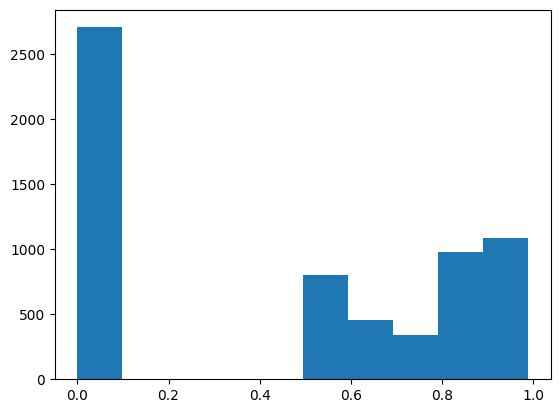

In [5]:
plt.hist(df_features_clean['TIME SYMPTOMES-ICU'])


In [6]:
import sys
sys.modules.pop('utils.feature_importance', None)
sys.modules.pop('utils.data_quality', None)
sys.modules.pop('utils.stats_dataset', None)
sys.modules.pop('utils.algo_prediction', None)

sys.modules.pop('utils.feature_transformer', None)
sys.modules.pop('utils.visualisation', None)
sys.modules.pop('utils.data_aug', None)
sys.modules.pop('utils.models_and_metrics', None) 

In [7]:
L = df_features_clean.columns
print(L)
print("Alveolar_cons_Focal" in L)

Index(['Sex', 'Time H-ICU', 'TIME SYMPTOMES-ICU', 'Time  DG-ICU', 'Sys_dis',
       'Solid_tumor', 'Organ_transpl', 'Drug_induced', 'Chemotherapy',
       'Ibr_Flu_Met', 'Immuno_drugs', 'Tar_ther', 'Immunotherapy',
       'Carttcells', 'Steroids_YN', 'Charlson_index',
       'Prophylaxis_pneumocystis', 'Prophylaxis_antifungal',
       'Prophylaxis_bacterial', 'Prophylaxis_viral', 'Vaccins#Flu',
       'Vaccins#COVID', 'Vaccins#Other', 'Glasgow', 'Hemoptysis',
       'PaO2/FiO2 VALUE VALUE', 'Pleural_eff', 'Quad_no', 'Excavation',
       'Septal_line', 'Halo_sign', 'Lymph_bulky', 'Age_scaled', 'Hem_mal_AML',
       'Hem_mal_ALL', 'Hem_mal_Non_hodgkin_lymphoma', 'Hem_mal_myeloma',
       'Hem_mal_hodgkin_lymphoma', 'Hem_mal_CLL', 'Hem_mal_CML', 'Hem_mal_MDS',
       'Hem_mal_other', 'Disease_status_inaugural', 'Disease_status_remission',
       'Disease_status_evolutive', 'rejet_allograft', 'HSCT_BMT_Autograft',
       'HSCT_BMT_Allograft', 'Nodules_any', 'GGO', 'SOFA_scaled', 'Sa02',
  

# Mapping classes

In [8]:
# format mapping_etiology[nvelle_col] = [old_col1,old_cold2 ,...]
mapping_etiology ={
                    'Bacterial infection' :['Bacterial infection'] ,
                    'Viral infection' :['Viral infection'] ,
                    'Invasive pulmonary aspergillosis' :['Invasive pulmonary aspergillosis'] ,
                    # 'All fungus' : ["Other fungal ",'Mucorales'],
                    'Other fungal' :["Other fungal "] ,
                    'Mucorales' : ['Mucorales'],
                    'Pneumocystis jirovecii infection' :[ 'Pneumocystis jirovecii infection'],
                    'Cardiogenic pulmonary oedema' : ['Cardiogenic pulmonary oedema'],
                    'Disease-related infiltrates':['Disease-related infiltrates'],
                    'Drug toxicity related' : ['Drug toxicity related'],
                    'Other non infectious causes': ['Other non infectious causes','Other infection ','Transfusion-related acute lung injury'],
                   # 'Undetermined cause':['Undetermined cause' ]
                    }
from utils.data_quality import fusionner_labels
print(df_cat_clean.columns)
df_labels_fusion = fusionner_labels(df_cat_clean, mapping_etiology, mode="max")
print((df_labels_fusion.sum(axis=0))/len(df_labels_fusion))


Index(['Bacterial infection', 'Viral infection',
       'Invasive pulmonary aspergillosis', 'Pneumocystis jirovecii infection',
       'Mucorales', 'Other fungal ', 'Other infection ',
       'Cardiogenic pulmonary oedema', 'Drug toxicity related',
       'Disease-related infiltrates', 'Transfusion-related acute lung injury',
       'Other non infectious causes'],
      dtype='object')
Bacterial infection                 0.435692
Viral infection                     0.288836
Invasive pulmonary aspergillosis    0.051572
Other fungal                        0.041509
Mucorales                           0.013836
Pneumocystis jirovecii infection    0.052358
Cardiogenic pulmonary oedema        0.132233
Disease-related infiltrates         0.121698
Drug toxicity related               0.041509
Other non infectious causes         0.338208
dtype: float64


# Model 1 classe

In [9]:
import random
from collections import defaultdict
import numpy as np
from utils.algo_prediction import preparer_jeu_xy, AutoStandardScaler
from utils.models_and_metrics import get_models, get_metric, negative_predictive_value,f1_metric_xgb,save_best_combo_config
from utils.data_aug import get_augmentation_methods
from utils.visualisation import show_metrics_binary, show_roc_curve,plot_model_bars
from utils.run_model import run_model_aug, run_config_for_target
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from pathlib import Path
import json
import csv


def find_best_model_and_aug(df_features_clean, 
                   df_labels_fusion, 
                   target_col,
                   MODEL_NAMES,
                   MAIN_METRIC_NAME,
                   write_config = False,
                   to_save = False,
                   save_dir = "artifacts/find_best",
                   random_seed = 42,
                   montecarlo = 5):
    """
    Lance l'experience pour une cible (diagnostic) en moyenne sur plusieurs tirages Monte Carlo.

    Parameters
    ----------
    df_features_clean : pd.DataFrame
        Features nettoyees.
    df_labels_fusion : pd.DataFrame
        Labels.
    target_col : str
        Colonne cible.
    MODEL_NAMES : list[str]
        Modeles a evaluer.
    MAIN_METRIC_NAME : str
        Nom de la metrique a optimiser.
    write_config : bool
        Sauvegarder la configuration gagnante.
    to_save : bool, default=False
        Sauvegarder les scores (CSV/JSON) et les graphes de performance dans un dossier.
    save_dir : str or Path
        Dossier parent pour stocker les exports (un sous-dossier par cible).
    random_seed : int
        Graine initiale.
    montecarlo : int, default=5
        Nombre d'iterations Monte Carlo (split/train/test) utilisees pour moyenner les scores.

    Returns
    -------
    dict contenant les informations du meilleur combo modele/augmentation.
    Si write_config=True, sauvegarde config_{diagnosis}.yaml.
    """

    def _slugify(value):
        clean = "".join(char if char.isalnum() else "_" for char in (value or ""))
        clean = clean.strip("_")
        return clean or "target"

    def _export_model_bars(scores_dict, title, output_path):
        model_names = list(scores_dict.keys())
        raw_values = list(scores_dict.values())

        means = []
        stds = []
        for value in raw_values:
            mean = value
            std = 0.0
            if isinstance(value, dict):
                mean = value.get("mean", value.get("avg_score", 0.0))
                std = value.get("std", value.get("std_score", 0.0))
            elif isinstance(value, (list, tuple)) and len(value) >= 2:
                mean, std = value[0], value[1]
            means.append(float(mean))
            stds.append(abs(float(std)))

        has_errors = any(std > 0 for std in stds)

        plt.figure(figsize=(8, 6))
        bars = plt.bar(
            model_names,
            means,
            yerr=stds if has_errors else None,
            capsize=5 if has_errors else None
        )
        plt.title(title)
        plt.xlabel("Modèles")
        plt.ylabel("Score")
        plt.xticks(rotation=45)

        for idx, bar in enumerate(bars):
            height = bar.get_height()
            if stds[idx] > 0:
                label = f"{height:.3f} ± {stds[idx]:.3f}"
            else:
                label = f"{height:.3f}"
            plt.text(bar.get_x() + bar.get_width()/2, height, label, ha="center", va="bottom")

        plt.tight_layout()
        plt.savefig(output_path, dpi=180)
        plt.close()

    target_save_dir = None
    if to_save:
        base_dir = Path(save_dir).expanduser()
        target_save_dir = base_dir / _slugify(target_col)
        target_save_dir.mkdir(parents=True, exist_ok=True)

    if random_seed is None:
        random_seed = 42

    def _compute_youden_threshold(y_true, y_score):
        fpr, tpr, thresholds = roc_curve(y_true, y_score)
        if len(thresholds) == 0:
            return 0.5, (fpr, tpr, thresholds)
        j_scores = tpr - fpr
        idx = int(np.argmax(j_scores))
        return float(thresholds[idx]), (fpr, tpr, thresholds)

    np.random.seed(random_seed)
    random.seed(random_seed)
    base_threshold = 0.11

    metrics = get_metric()
    metric_entry = metrics[MAIN_METRIC_NAME]
    metric_fn = metric_entry["metric_fn"]
    needs_proba = metric_entry["needs_proba"]

    combo_tracker = defaultdict(lambda: {"scores": [], "best_entry": None})
    model_best_scores = {}
    model_best_aug = {}
    model_best_entries = {}
    combined_roc_data = []

    best_result = {
        "score": float('-inf'),
        "score_mean": float('-inf'),
        "score_std": 0.0,
        "youden_threshold": None,
        "model_name": None,
        "augmentation_name": None,
        "pipe_train": None,
        "pipe_inference": None,
        "y_pred": None,
        "y_test": None
    }

    df_features_to_use = df_features_clean

    df_labels_1 = df_labels_fusion[target_col].to_frame()
    print("====", target_col, "====")

    for mc_idx in range(montecarlo):
        current_seed = random_seed + mc_idx
        X_train, X_test, y_train, y_test, labels = preparer_jeu_xy(df_features_to_use, df_labels_1, random_state=current_seed)

        all_models = get_models(y_train, use_catboost=True,imbalance_threshold=0.1, random_state=current_seed)
        augmentations = get_augmentation_methods(random_state=current_seed)

        if hasattr(y_test, "to_numpy"):
            y_test_array = y_test.to_numpy()
        else:
            y_test_array = np.asarray(y_test)

        print(f"Monte Carlo {mc_idx + 1}/{montecarlo} (seed={current_seed})")

        for model_name in MODEL_NAMES:
            if model_name not in all_models:
                print(f"{model_name} indisponible dans la librairie de modeles, combo ignore.")
                continue
            base_model = all_models[model_name]

            for augmentation_name, augmentation in augmentations.items():
                result = run_model_aug(
                    model_name=model_name,
                    base_model=base_model,
                    augmentation_name=augmentation_name,
                    augmentation=augmentation,
                    X_train=X_train,
                    X_test=X_test,
                    y_train=y_train,
                    y_test=y_test,
                    MAIN_METRIC_NAME=MAIN_METRIC_NAME,
                    metric_fn=metric_fn,
                    needs_proba=needs_proba,
                    THRESHOLD=base_threshold,
                    target_col=target_col,
                    feature_names=X_train.columns,
                    verbose=False
                )

                score = result["score"]
                combo_key = (model_name, augmentation_name)
                entry = combo_tracker[combo_key]
                entry["scores"].append(score)

                if entry["best_entry"] is None or score > entry["best_entry"]["score"]:
                    entry["best_entry"] = {
                        "score": score,
                        "result": result,
                        "y_test": y_test_array
                    }

    if not combo_tracker:
        print("Aucun combo valide.")
        return best_result

    for (model_name, augmentation_name), entry in combo_tracker.items():

        scores = entry["scores"]
        avg_score = float(np.mean(scores))
        std_score = float(np.std(scores)) if len(scores) > 1 else 0.0

        if avg_score > best_result["score_mean"]:
            best_entry = entry["best_entry"]
            best_result.update({
                "score": best_entry["score"],
                "score_mean": avg_score,
                "score_std": std_score,
                "model_name": model_name,
                "augmentation_name": augmentation_name,
                "pipe_train": best_entry["result"]["pipe_train"],
                "pipe_inference": best_entry["result"]["pipe_inference"],
                "y_pred": best_entry["result"]["y_pred"],
                "y_test": best_entry["y_test"]
            })

        current_best = model_best_scores.get(model_name, float('-inf'))
        if avg_score > current_best:
            model_best_scores[model_name] = avg_score
            model_best_aug[model_name] = augmentation_name
            model_best_entries[model_name] = {
                "avg_score": avg_score,
                "std_score": std_score,
                "entry": entry["best_entry"]
            }

    best_model_name = best_result["model_name"]
    best_aug_name = best_result["augmentation_name"]

    if best_model_name is not None:
        best_avg = best_result["score_mean"]
        if not np.isfinite(best_avg):
            best_avg = best_result["score"]
        print(
            f"Meilleur combo -> Modele: {best_model_name} | Augmentation: {best_aug_name} | "
            f"{MAIN_METRIC_NAME} (moyenne MC): {best_avg:.4f} | std: {best_result['score_std']:.4f} | "
            f"meilleur run: {best_result['score']:.4f}"
        )

    best_y_pred = best_result["y_pred"]
    best_y_test = best_result["y_test"]

    if best_y_pred is not None and best_y_test is not None:
        best_threshold, best_roc_points = _compute_youden_threshold(best_y_test, best_y_pred)
        best_result["youden_threshold"] = best_threshold
        y_pred_bin = (best_y_pred > best_threshold).astype(int)
        print(
            "Negative Predictive Value (best combo, seuil Youden {:.3f}): {}".format(
                best_threshold, negative_predictive_value(best_y_test, y_pred_bin)
            )
        )

    if model_best_entries:
        labelled_scores = {
            f"{model} ({model_best_aug[model]})": (data["avg_score"], data["std_score"])
            for model, data in model_best_entries.items()
        }
        plot_model_bars(labelled_scores, title=f"Meilleure augmentation par modele - {target_col}")

        if to_save and target_save_dir is not None:
            score_records = []
            for model_name, data in model_best_entries.items():
                entry = data["entry"]
                youden_threshold, _ = _compute_youden_threshold(entry["y_test"], entry["result"]["y_pred"])
                score_records.append({
                    "target": target_col,
                    "model_name": model_name,
                    "augmentation_name": model_best_aug[model_name],
                    "avg_score": float(data["avg_score"]),
                    "std_score": float(data["std_score"]),
                    "best_run_score": float(entry["score"]),
                    "youden_threshold": float(youden_threshold),
                    "main_metric": MAIN_METRIC_NAME,
                    "montecarlo_runs": montecarlo,
                    "random_seed": random_seed
                })

            if score_records:
                csv_path = target_save_dir / "scores_summary.csv"
                fieldnames = [
                    "target",
                    "model_name",
                    "augmentation_name",
                    "avg_score",
                    "std_score",
                    "best_run_score",
                    "youden_threshold",
                    "main_metric",
                    "montecarlo_runs",
                    "random_seed"
                ]
                with csv_path.open("w", newline="", encoding="utf-8") as handle:
                    writer = csv.DictWriter(handle, fieldnames=fieldnames)
                    writer.writeheader()
                    writer.writerows(score_records)

                json_path = target_save_dir / "scores_summary.json"
                with json_path.open("w", encoding="utf-8") as handle:
                    json.dump(score_records, handle, indent=2)

                bars_path = target_save_dir / "scores_bar.png"
                _export_model_bars(
                    labelled_scores,
                    title=f"Meilleure augmentation par modele - {target_col}",
                    output_path=bars_path
                )

        print("\nCourbes ROC des meilleures augmentations par modele :")
        for model_name, data in model_best_entries.items():
            augmentation_name = model_best_aug[model_name]
            avg_score = data["avg_score"]
            std_score = data["std_score"]
            entry = data["entry"]
            youden_threshold, roc_points = _compute_youden_threshold(entry["y_test"], entry["result"]["y_pred"])
            print(
                f"- {model_name} ({augmentation_name}) — {MAIN_METRIC_NAME} moyen = {avg_score:.4f} ± {std_score:.4f} "
                f"| seuil Youden = {youden_threshold:.4f}"
            )
            combined_roc_data.append({
                "model_name": model_name,
                "augmentation_name": augmentation_name,
                "roc_points": roc_points,
                "youden_threshold": youden_threshold,
                "avg_score": avg_score,
                "std_score": std_score
            })

        if combined_roc_data:
            fig, ax = plt.subplots(figsize=(7, 7))
            for item in combined_roc_data:
                fpr, tpr, thresholds = item["roc_points"]
                label = (
                    f"{item['model_name']} ({item['augmentation_name']}) - "
                    f"{item['avg_score']:.3f}±{item['std_score']:.3f}"
                )
                ax.plot(fpr, tpr, lw=2, label=label)

                threshold = item["youden_threshold"]
                if len(thresholds) > 0:
                    highlight_idx = int(np.argmin(np.abs(thresholds - threshold)))
                    ax.scatter(
                        fpr[highlight_idx],
                        tpr[highlight_idx],
                        s=70,
                        edgecolor="black",
                        linewidth=0.8
                    )

            ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)
            ax.set_xlim([0.0, 1.0])
            ax.set_ylim([0.0, 1.05])
            ax.set_xlabel("False Positive Rate")
            ax.set_ylabel("True Positive Rate")
            ax.set_title(f"ROC - meilleures augmentations ({target_col})")
            ax.legend(loc="lower right")
            ax.grid(True)
            fig.tight_layout()

            if to_save and target_save_dir is not None:
                roc_fig_path = target_save_dir / "roc_curves.png"
                fig.savefig(roc_fig_path, dpi=180)

                roc_payload = []
                for roc_item in combined_roc_data:
                    fpr, tpr, thresholds = roc_item["roc_points"]
                    roc_payload.append({
                        "model_name": roc_item["model_name"],
                        "augmentation_name": roc_item["augmentation_name"],
                        "avg_score": float(roc_item["avg_score"]),
                        "std_score": float(roc_item["std_score"]),
                        "youden_threshold": float(roc_item["youden_threshold"]),
                        "fpr": np.asarray(fpr).tolist(),
                        "tpr": np.asarray(tpr).tolist(),
                        "thresholds": np.asarray(thresholds).tolist()
                    })
                roc_json_path = target_save_dir / "roc_curves.json"
                with roc_json_path.open("w", encoding="utf-8") as handle:
                    json.dump(roc_payload, handle, indent=2)

            plt.show()
            plt.close(fig)

    if to_save and target_save_dir is not None and best_result["model_name"] is not None:
        youden_value = best_result.get("youden_threshold")
        if youden_value is not None and np.isfinite(youden_value):
            youden_value = float(youden_value)
        else:
            youden_value = None
        best_export = {
            "target": target_col,
            "model_name": best_result["model_name"],
            "augmentation_name": best_result["augmentation_name"],
            "main_metric": MAIN_METRIC_NAME,
            "score_mean": float(best_result["score_mean"]),
            "score_std": float(best_result["score_std"]),
            "best_run_score": float(best_result["score"]),
            "youden_threshold": youden_value,
            "montecarlo_runs": montecarlo,
            "random_seed": random_seed
        }
        best_summary_path = target_save_dir / "best_result.json"
        with best_summary_path.open("w", encoding="utf-8") as handle:
            json.dump(best_export, handle, indent=2)

    if write_config and best_result["model_name"] is not None:
        score_to_save = best_result["score_mean"]
        if not np.isfinite(score_to_save):
            score_to_save = best_result["score"]
        threshold_to_save = best_result.get("youden_threshold")
        if threshold_to_save is None or not np.isfinite(threshold_to_save):
            threshold_to_save = base_threshold
        save_best_combo_config(
            target_col,
            best_result["model_name"],
            best_result["augmentation_name"],
            MAIN_METRIC_NAME,
            score_to_save,
            threshold_to_save,
            random_seed=random_seed
        )
    elif write_config:
        print('Impossible de sauvegarder la configuration : aucun combo valide.')

    return best_result



In [ ]:
import os 
target_col =  'Bacterial infection'
os.path.exists(r"C:\Users\romai\Desktop\travail\avancement\model_grid_search\\" )

True

==== Bacterial infection ====

📊 Répartition des classes : pos=0.436, neg=0.564
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 1/5 (seed=42)

📊 Répartition des classes : pos=0.436, neg=0.564
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 2/5 (seed=43)

📊 Répartition des classes : pos=0.436, neg=0.564
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 3/5 (seed=44)

📊 Répartition des classes : pos=0.436, neg=0.564
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 4/5 (seed=45)

📊 Répartition des classes : pos=0.436, neg=0.564
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 5/5 (seed=46)
Meilleur combo -> Modele: Random Forest | Augmentation: No Augmentation | roc_auc (moyenne MC): 0.8227 | std: 0.0046 | meilleur run: 0.8305
Negative Predictive Value (best com

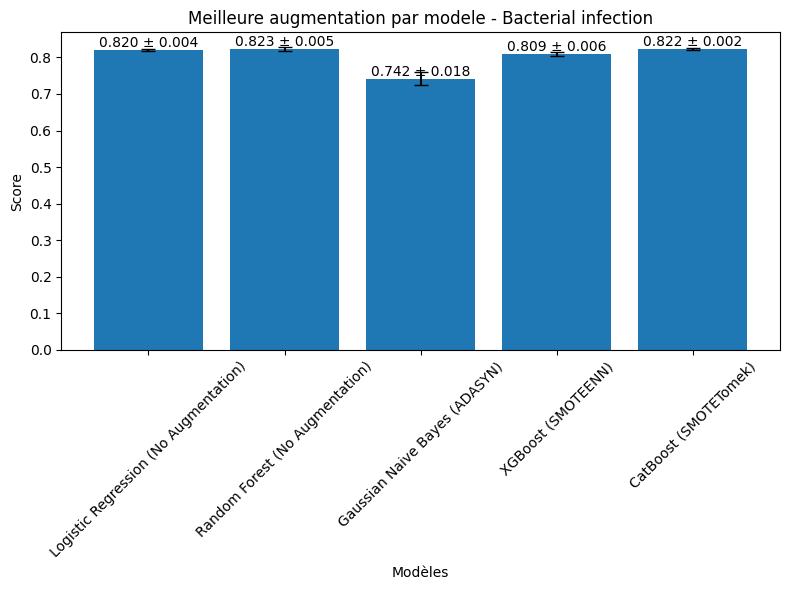


Courbes ROC des meilleures augmentations par modele :
- Logistic Regression (No Augmentation) — roc_auc moyen = 0.8204 ± 0.0035 | seuil Youden = 0.3450
- Random Forest (No Augmentation) — roc_auc moyen = 0.8227 ± 0.0046 | seuil Youden = 0.4367
- Gaussian Naive Bayes (ADASYN) — roc_auc moyen = 0.7416 ± 0.0183 | seuil Youden = 0.5887
- XGBoost (SMOTEENN) — roc_auc moyen = 0.8095 ± 0.0060 | seuil Youden = 0.2166
- CatBoost (SMOTETomek) — roc_auc moyen = 0.8224 ± 0.0022 | seuil Youden = 0.3472


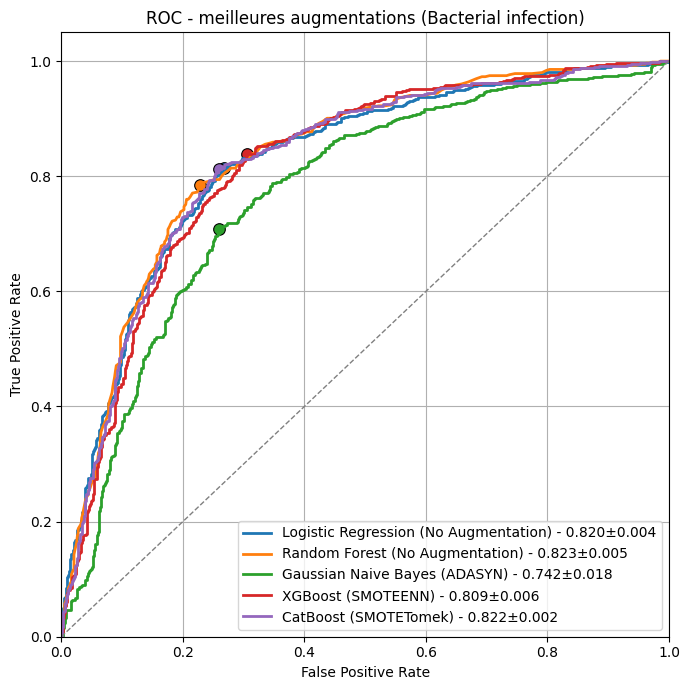

Configuration sauvegard?e dans config_Bacterial infection.yaml


In [20]:
RANDOM_SEED = 42
import os 
target_col =  'Bacterial infection'
# os.mkdir(r"C:\Users\romai\Desktop\travail\avancement\model_grid_search\\" + target_col + "\\")
MODEL_NAMES = ['Logistic Regression', 'Random Forest', 'Gaussian Naive Bayes', 'XGBoost',"CatBoost"]
# MODEL_NAMES =  ['Random Forest']
save_dir = r"C:\Users\romai\Desktop\travail\avancement\model_grid_search"
MAIN_METRIC_NAME = 'roc_auc'
_ = find_best_model_and_aug(df_features_clean, 
                   df_labels_fusion, 
                   target_col,
                   MODEL_NAMES,
                   MAIN_METRIC_NAME,
                   write_config = True,
                   random_seed=RANDOM_SEED,
                   to_save = True,
                   save_dir = r"C:\Users\romai\Desktop\travail\avancement\model_grid_search\\")



📊 Répartition des classes : pos=0.054, neg=0.946
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

==== All fungus ====
Meilleur combo -> Modele: Random Forest | Augmentation: SMOTE | roc_auc: 0.7908
Negative Predictive Value (best combo): 0.9817945383615084


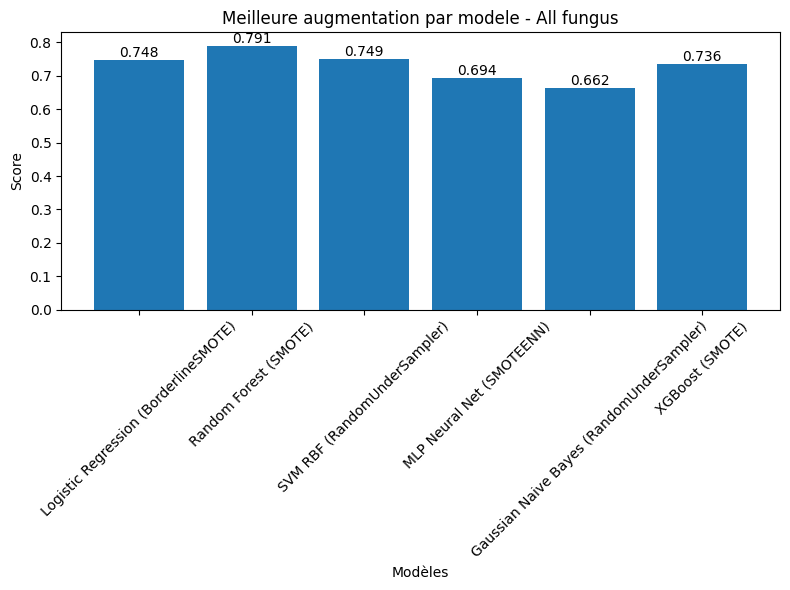

Configuration sauvegard?e dans config_All fungus.yaml


In [66]:
df_labels_fusion.columns
# big loop 
#for target_col in df_labels_fusion.columns:
target_col = 'All fungus'
MODEL_NAMES = ['Logistic Regression', 'Random Forest', 'SVM RBF', 'MLP Neural Net', 'Gaussian Naive Bayes', 'XGBoost']
# MODEL_NAMES =  ['Random Forest']
MAIN_METRIC_NAME = 'roc_auc'
features_sensibilite =  ["Neutropenie", "Prophylaxis_antifungal"]
_ = find_best_model_and_aug(df_features_clean, 
                df_labels_fusion, 
                target_col,
                MODEL_NAMES,
                MAIN_METRIC_NAME,
                write_config = True,
                random_seed=RANDOM_SEED)


# A implementer

In [26]:
df_labels_1 = df_labels_fusion[target_col].to_frame()
X_train, X_test, y_train, y_test, labels = preparer_jeu_xy(df_features_clean, df_labels_1)

model = get_models(y_train, use_catboost=False)['Random Forest']
from utils.feature_importance import _ensure_estimators
_ensure_estimators(model)


📊 Répartition des classes : pos=0.132, neg=0.868
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing



[RandomForestClassifier(class_weight='balanced', n_estimators=300)]

In [ ]:
df_labels_fusion.columns


Index(['Bacterial infection', 'Viral infection',
       'Invasive pulmonary aspergillosis', 'Other fungal', 'Mucorales',
       'Pneumocystis jirovecii infection', 'Cardiogenic pulmonary oedema',
       'Disease-related infiltrates', 'Drug toxicity related',
       'Other non infectious causes'],
      dtype='object')


📊 Répartition des classes : pos=0.436, neg=0.564
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Chargement configuration : c:\Users\romai\Desktop\codes\respiratory_diagnostics\configs\config_Bacterial infection.yaml
Modèle = Random Forest | Augmentation = No Augmentation | Métrique = roc_auc
----- run_model_aug -----
target_col=Bacterial infection
model=Random Forest
augmentation=No Augmentation
metric=roc_auc | threshold=0.43666666666666665
show_roc=True, show_importance=False, show_shap=False
sensibilite=False, type_sensi=all
features_sensibilite=['Neutropenie', 'Prophylaxis_antifungal']
Random Forest | No Augmentation -> roc_auc: 0.8193
Negative Predictive Value: 0.7961876832844574


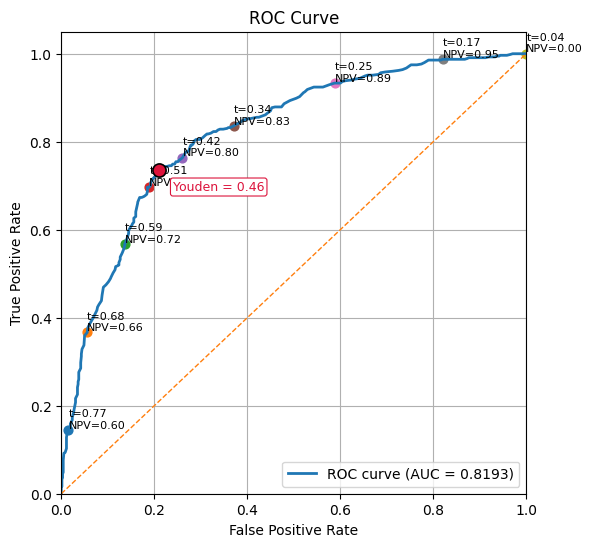

ROC AUC = 0.8193
Negative Predictive Value youden: 0.793006993006993 threshold  0.4633333333333333
Impossible de calculer at_least_one_correct : axis 1 is out of bounds for array of dimension 1
Impossible de calculer reject_n_lowest_correct : invalid index to scalar variable.


In [22]:
sys.modules.pop('utils.run_model',None)
from utils.run_model import run_config_for_target
import os 
config_dir = os.getcwd() + '\\configs\\'
target_col = 'Bacterial infection'
# cols = [ 'Other fungal', 'Mucorales',
#        'Pneumocystis jirovecii infection', 'Cardiogenic pulmonary oedema',
#        'Disease-related infiltrates', 'Drug toxicity related',
#        'Other non infectious causes']
features_sensibilite = ["Neutropenie", "Prophylaxis_antifungal"]
# for target_col in cols:
# condition = lambda X: (X["HSCT_BMT_Autograft"] == 1) 
run_output = run_config_for_target(target_col,
                        df_features_clean,
                        df_labels_fusion,
                        sensibilite = False,
                        show_importance = False,
                        show_roc = True,
                        show_shap = False,
                        
                        features_sensibilite = features_sensibilite,
                        type_sensi = 'all',
                        method_importance = 'native_importance',
                        config_dir = config_dir,
                        condition_test=None)

In [27]:
run_output['metric_scores']

{'accuracy': 0.7531446540880503,
 'precision': 0.7033898305084746,
 'recall': 0.7490974729241877,
 'f1': 0.7255244755244755,
 'f_beta': 0.7255244755244755,
 'negative_predictive_value': np.float64(0.7961876832844574),
 'lr_positive': np.float64(3.0734399174832387),
 'lr_negative': np.float64(0.33176429915365235),
 'roc_auc': 0.819345001659242,
 'pr_auc': 0.7651888031389938,
 'logloss': 0.5243950862761829,
 'brier': 0.17304695143256463}

In [ ]:
import huggingface_hub
huggingface_hub.login()
features_hemato =['Hem_mal_AML', 'Hem_mal_ALL', 'Hem_mal_Non_hodgkin_lymphoma',
       'Hem_mal_myeloma', 'Hem_mal_hodgkin_lymphoma', 'Hem_mal_CLL',
       'Hem_mal_CML', 'Hem_mal_MDS', 'Hem_mal_other']

features_sensibilite = ["Neutropenie", "Prophylaxis_antifungal"]

diag_selected = [
    'Invasive pulmonary aspergillosis', 
    'Pneumocystis jirovecii infection',
    'Cardiogenic pulmonary oedema',
    'Disease-related infiltrates',
    # 'Viral infection',
]
#target_col = 'Cardiogenic pulmonary oedema'

MODEL_NAMES = ['Logistic Regression', 'Random Forest', 'SVM RBF', 'MLP Neural Net', 'Gaussian Naive Bayes', 'XGBoost']
#MODEL_NAMES = ['TabPFN']
MODEL_NAMES =  ['Random Forest']
MAIN_METRIC_NAME = 'roc_auc'
THRESHOLD = 0.11
for target_col in diag_selected:
    run_config_for_target(df_features_clean, 
                   df_labels_fusion, 
                   target_col,
                   MODEL_NAMES,
                   MAIN_METRIC_NAME,
                   THRESHOLD,
                   sensibilite = False,
                   show_roc = False,
                   show_importance=True,
                   features_sensibilite = features_sensibilite ,
                   type_sensi = 'all')


In [64]:
-0.0058 / 0.178

-0.03258426966292135

In [51]:
import huggingface_hub
huggingface_hub.login()

# Multioutput

In [2]:
from imblearn.pipeline import Pipeline
from utils.algo_prediction import preparer_jeu_xy

from utils.algo_prediction import AutoStandardScaler
from utils.models_and_metrics import get_models,get_metric,f1_metric_xgb
from utils.data_aug import get_augmentation_methods
from utils.visualisation import show_metrics_binary, show_roc_curve
from utils.models_and_metrics import negative_predictive_value
from sklearn.metrics import (roc_auc_score)
from utils.visualisation import multilabel_roc
import numpy as np
X_train, X_test, y_train, y_test, labels = preparer_jeu_xy(df_features_clean,df_labels_fusion) 

models = get_models(y_train,multilabel=True,imbalance_threshold=0.01,use_catboost=False)
augmentations = get_augmentation_methods(random_state=0)
print(augmentations.keys())

metrics = get_metric()
print(metrics.keys())

results = []
metrique = f1_metric_xgb
for model_name, model in models.items():
    print("Model:", model_name)
    
    pipe_train = Pipeline([
        ("scaler", AutoStandardScaler()),
        # ("augmentation", augmentations['SMOTE']),
        ("model",model )
    ])
    # Changement de la métrique plus tard
    # pipe_train.set_params(model__eval_metric=f1_metric_xgb)


    pipe_train.fit(X_train, y_train)

    metric_fn=metrics['roc_auc']["metric_fn"]
    needs_proba=metrics['roc_auc']["needs_proba"]


    pipe_test = Pipeline([
        ("scaler", pipe_train.named_steps["scaler"]),  # scaler déjà fit
        ("model", pipe_train.named_steps["model"])     # modèle déjà fit
    ])

    if needs_proba:
        y_pred = pipe_test.predict_proba(X_test)
    else:
        y_pred = pipe_test.predict(X_test)
    probas_array = np.column_stack([p[:, 1] for p in y_pred])

    a = multilabel_roc(
        np.array(y_test), probas_array,
        plot=True,
        label_names=y_test.columns.to_list(),
        per_label_max=8,   # ne tracer que les 8 meilleures courbes par label
        show_micro=True,
        show_macro=True
        )

    # score = roc_auc_score(y_test, y_pred, average="macro")
    # show_metrics_binary(y_test, y_pred)
    # show_roc_curve(y_test, y_pred)
    # print("Negative Predictive Value:", negative_predictive_value(y_test, y_pred))

NameError: name 'df_features_clean' is not defined

In [ ]:
from utils.models_and_metrics import get_models_multilabel, compare_models_metric, get_metric
from sklearn.metrics import hamming_loss
from sklearn.metrics import f1_score
from utils.algo_prediction import preparer_jeu_xy,normaliser_features,train_and_optimize_threshold_PR
# Charger les mod?les multilabel sp?cialis?s
models = get_models_multilabel()

metrics = get_metric()
# print(metrics['f1']'metric_fn')
# Pr?parer les donn?es
X_train, X_test, y_train, y_test, labels = preparer_jeu_xy(df_features_clean, df_labels_fusion)

# Comparer avec une m?trique multilabel
df_scores = compare_models_metric(
    models,
    metric_fn=f1_score,  # ou f1_score avec un autre average
    metric_kwargs={"average": "weighted"},
    metric_name="f1_weighted",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    needs_proba=False
)

print(df_scores)


# SHAP values

In [ ]:
sys.modules.pop('utils.feature_importance', None)
from utils.feature_importance import shap_top10_per_estimator,plot_top10_features_per_estimator
plot_top10_features_per_estimator(modele,feature_names=X_train.columns,col_names=y_train.columns,to_save=True,dir_save='E:/graphs_bdd/importance')
shap_top10_per_estimator(model= modele,X = X_test_sc,col_names=y_train.columns,to_save=True,dir_save='E:/graphs_bdd/shap')

In [ ]:
from utils.stats_dataset import analyze_collinearity
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
from utils.feature_transformer import transform_features, _convert_all_columns_to_numeric
from utils.data_quality import nettoyer_nan_par_colonne
Liste_features = Liste_features_simple #+ features_radiology_dysfunction
df_col_utils = df[Liste_features]
df_category = df[features_etiology]
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","Neutrophils","Temp","Sp02","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}
df_col_utils = _convert_all_columns_to_numeric(df_col_utils)
# print(df_col_utils.columns)

df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
df_features_clean = _convert_all_columns_to_numeric(df_features_clean)

df_category = nettoyer_colonnes(df_category)
df_cat_clean = nettoyer_lignes_vides(df_category)
df_col_utils = nettoyer_lignes_vides(df_col_utils)
vif_results = analyze_collinearity(df_col_utils)
vif_results_clean = analyze_collinearity(df_features_clean)




In [ ]:
df_col_utils.isna().any().any()
# print(df_features_clean.isna().sum()[df_features_clean.isna().sum() > 0])


In [ ]:
L_radio = ['Alveolar_xray_No', 'Alveolar_xray_Focal',
       'Alveolar_xray_Diffuse', 'Interst_xray_No', 'Interst_xray_Focal',
       'Interst_xray_Diffuse', 'Alveolar_cons_No', 'Alveolar_cons_Focal',
       'Alveolar_cons_Diffuse', 'Ground_glass_op_No', 'Ground_glass_op_Focal',
       'Ground_glass_op_Diffuse', 'rejet_allograft', 'HSCT_BMT_Autograft',
       'HSCT_BMT_Allograft', 'SOFA_scaled', 'Sa02', 'Resp_severity',
       'Temp_gravité', 'Neutropenie']
for x in L_radio:
    print(df_features_clean[x].value_counts())

In [ ]:
df_features_clean.iloc[0]

In [ ]:
Implémenter from sklearn.model_selection import StratifiedKFold
